<a href="https://colab.research.google.com/github/lmendezayl/uba-optimizacion/blob/main/laboratorios/laboratorio3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import Pkg
Pkg.add("MAT")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed aws_c_cal_jll ───────── v0.9.13+0
   Installed aws_c_sdkutils_jll ──── v0.2.4+1
   Installed MicrosoftMPI_jll ────── v10.1.4+3
   Installed MPIABI_jll ──────────── v0.1.5+0
   Installed aws_c_auth_jll ──────── v0.9.6+0
   Installed StringEncodings ─────── v0.3.7
   Installed Hwloc_jll ───────────── v2.13.0+1
   Installed MAT ─────────────────── v0.12.0
   Installed aws_c_common_jll ────── v0.12.6+0
   Installed s2n_tls_jll ─────────── v1.7.2+0
   Installed HDF5_jll ────────────── v2.1.2+0
   Installed MPICH_jll ───────────── v5.0.1+0
   Installed aws_c_http_jll ──────── v0.10.13+0
   Installed MPIPreferences ──────── v0.1.12
   Installed libaec_jll ──────────── v1.1.6+0
   Installed HDF5 ────────────────── v0.17.3
   Installed OpenMPI_jll ─────────── v5.0.11+0
   Installed aws_c_io_jll ────────── v0.26.3+0
   Installed XML2_jll ────────────── v2.13.9+0
   Installed dlfcn_win32_jll 

In [159]:
using MAT, LinearAlgebra, Plots, Statistics

file = matopen("datos.mat")

30×2 Matrix{Float64}:
 -6.95119  -0.852138
 -6.35938  -1.95546
 -7.17968   0.548569
 -6.88383  -0.705747
 -7.14634   0.513979
 -6.14825  -2.75174
 -5.59715  -3.15412
 -7.01545  -0.562753
 -6.3144   -2.35673
 -7.1555   -0.261855
 -6.53992  -1.4776
 -5.84086  -3.06353
 -6.60311  -1.9317
  ⋮        
  6.47583   4.45392
  6.10101   5.43871
  6.86631   3.79629
  6.99678   3.87232
  7.198     2.13198
  7.27782   1.56487
  7.24191   3.10104
  7.0884    3.22622
  6.41618   5.03305
  5.34357   6.40245
  5.45241   6.3372
  6.86886   4.00125

## Ejercicio 1

Implementar las siguientes funciones:
- 1. una función que retorne el vector $d(\theta)$
- 2. una función que retorne el valor de $F$,
- 3. una función que calcule la matriz diferencial $J$ de dependiendo del $\theta_0$.

In [3]:
function d(x, y, theta)
    a, b, r = theta
    d_value = sqrt.((x.- a).^2 + (y.- b).^2) .- r
    return d_value
end

d (generic function with 1 method)

In [4]:
function F(x, y, theta)
    distancias = d(x, y, theta)
    F_value = sum(distancias.^2)
    return F_value
end

F (generic function with 1 method)

In [5]:
function J(x, y, theta)
    n = length(x)
    a, b, r = theta
    J = zeros(n, 3)
    dist_centros = sqrt.((x.- a).^2 + (y.- b).^2)
    for i in 1:n
        J[i, 1] = -(x[i] - a) / dist_centros[i]
        J[i, 2] = -(y[i] - b) / dist_centros[i]
        J[i, 3] = -1.0
    end
    return J
end

J (generic function with 1 method)

In [155]:
function ajuste_geom(x, y, theta, eps=1e-8, max_iter=100)
    thetas = zeros(max_iter+1, 3)
    thetas[1, :] = theta
    for iter in 1:max_iter
        d_k = d(x, y, theta)
        J_k = J(x, y, theta)
        delta_theta = J_k \ -d_k
        theta = theta + delta_theta
        thetas[iter+1, :] = theta
        if norm(delta_theta) < eps
            println("converge en iteración $iter")
            return theta, thetas[1:iter, :]
        end
    end
    println("se alcanzó maximo de iteraciones")
    return theta, thetas
end

ajuste_geom (generic function with 3 methods)

converge en iteración 50


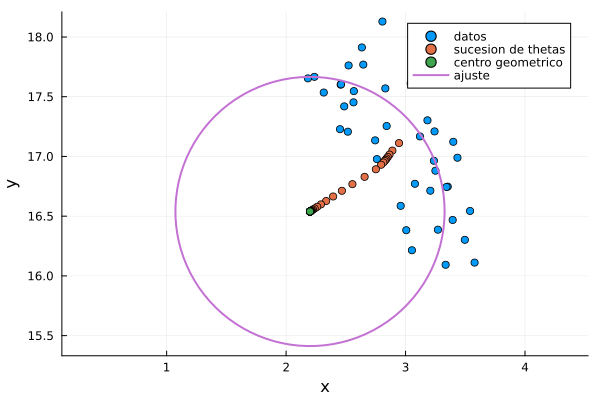

In [190]:
datos = read(file, "datos_5")
x = datos[:, 1]
y = datos[:, 2]
a0, b0, r0 = mean(x), mean(y), 6
theta0 = [a0, b0, r0]
theta, thetas = ajuste_geom(x, y, theta0)
a, b, r = theta
radian_range = range(0, 2π, length=100)
cx = a .+ r .* cos.(radian_range)
cy = b .+ r .* sin.(radian_range)
scatter(x, y, label="datos", xlabel="x", ylabel="y", aspect_ratio=:equal)
scatter!(thetas[:, 1], thetas[:, 2], label="sucesion de thetas")
scatter!([a], [b], label="centro geometrico")
plot!(cx, cy, label="ajuste", lw=2)

In [202]:
function ajuste_geom_svd(x, y, theta, eps=1e-8, max_iter=100)
    thetas = zeros(max_iter+1, 3)
    thetas[1, :] = theta
    for iter in 1:max_iter
        d_k = d(x, y, theta)
        J_k = J(x, y, theta)
        U_k , S_k, V_k = svd(J_k)
        sv_max, sv_min = S_k[1], S_k[3]
        k = sv_max / sv_min
        if k < 10^7 # 6-7 digitos de precisión perdidos está bien supuestamente
            delta_theta = pinv(J_k) * (-d_k)
            theta = theta + delta_theta
            thetas[iter+1, :] = theta
        else
            println("la matriz J está mal condicionada (k=$k)en iteración $iter")
            return theta, thetas[1:iter, :]
        end

        if norm(delta_theta) < eps
            println("converge en iteración $iter")
            return theta, thetas[1:iter, :]
        end
    end
    println("se alcanzó maximo de iteraciones")
    return theta, thetas
end

ajuste_geom_svd (generic function with 3 methods)

In [211]:
datos = read(file, "datos_7")
x = datos[:, 1]
y = datos[:, 2]
a0, b0, r0 = mean(x), mean(y), 6
theta0 = [a0, b0, r0]
theta, thetas = ajuste_geom_svd(x, y, theta0)
a, b, r = theta
radian_range = range(0, 2π, length=100)
cx = a .+ r .* cos.(radian_range)
cy = b .+ r .* sin.(radian_range)
scatter(x, y, label="datos", xlabel="x", ylabel="y", aspect_ratio=:equal)
scatter!(thetas[:, 1], thetas[:, 2], label="sucesion de thetas")
scatter!([a], [b], label="centro geometrico")
plot!(cx, cy, label="ajuste", lw=2)

20×2 Matrix{Float64}:
 4.86253  0.815431
 4.91099  0.646726
 4.82741  0.816332
 4.96551  0.487936
 4.81037  0.625494
 4.86405  0.748707
 4.93448  0.537493
 4.99337  0.646541
 5.04905  0.607673
 4.93035  0.601531
 4.59649  1.17196
 4.54658  1.2069
 4.59519  0.977849
 4.51004  1.1737
 4.59812  1.10143
 4.61695  1.1001
 4.62222  1.10574
 4.64637  1.07836
 4.41689  1.31404
 4.38942  1.27194